# Imports

In [120]:
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Helper functions

In [121]:
def det(X):
  return np.linalg.det(X)

def inv(X):
  return np.linalg.inv(X)

# Basis functions

In [122]:
def identity_bf(X):
  return X

def radial_bf(X, centers, lambdaval):
  d = X[:, np.newaxis] - centers[np.newaxis, :]
  y = np.exp(-0.5 * (d ** 2) / lambdaval)
  return y

def polynomial_bf(X, pow):
  return X ** pow

# Load and format data

In [123]:
real_data = pd.read_csv("./data/vattuniemi.csv")
generated_data = pd.read_csv("./data/generated_data.csv")
data = generated_data
#display(data)

# Pick features and labels
X = data[["Area", "Volume", "Storeys"]]
# Scale down to achieve sufficient accuracy for radial bf's
#X["Area"] = X["Area"].map(lambda area: area / 10000)
#X["Volume"] = X["Volume"].map(lambda volume: volume / 10000)
X = X.values
concrete = data[["Concrete"]].values
mineral_wool = data[["Mineral_wool"]].values
metal = data[["Metal"]].values
glass = data[["Glass"]].values


# Implement Bayesian linear regression

In [124]:
def BLR(X, y, alpha, beta, mu_0):

  N, F = X.shape

  # Posterior mean mu and covariance matrix S
  S_inv = beta * (X.T @ X) + alpha * np.identity(F)
  S = inv(S_inv)
  mu = S @ ((beta * X.T @ y).flatten() + alpha * mu_0)

  # Log-likelihood (Barber 18.1.19)
  d = (beta * X.T @ y).flatten() + alpha * mu_0
  
  log_lik = 0.5 * (-beta * y.T @ y + d.T @ S @ d + np.log(det(2 * np.pi * S))
            + F * np.log(alpha) + N * np.log(beta) - N * np.log(2 * np.pi))
  #log_lik = -0.5 * np.log(det(2 * np.pi * S)) - 0.5 * y.T @ S_inv
  #log_lik = 0.5 * (-beta * y.T @ y + d.T @ S @ d)

  return mu, S, log_lik

,Parameter,Value
0,alpha,0.000001
1,beta,0.00001
2,mu0,"[4, 22, 3]"


[3485.89109877 2773.18870418 2414.7997399  3226.02178102 3247.22091547
 3123.03962674]


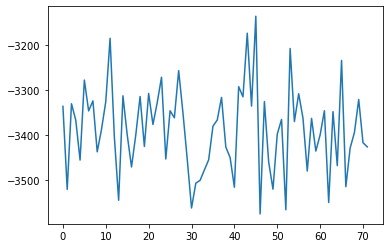

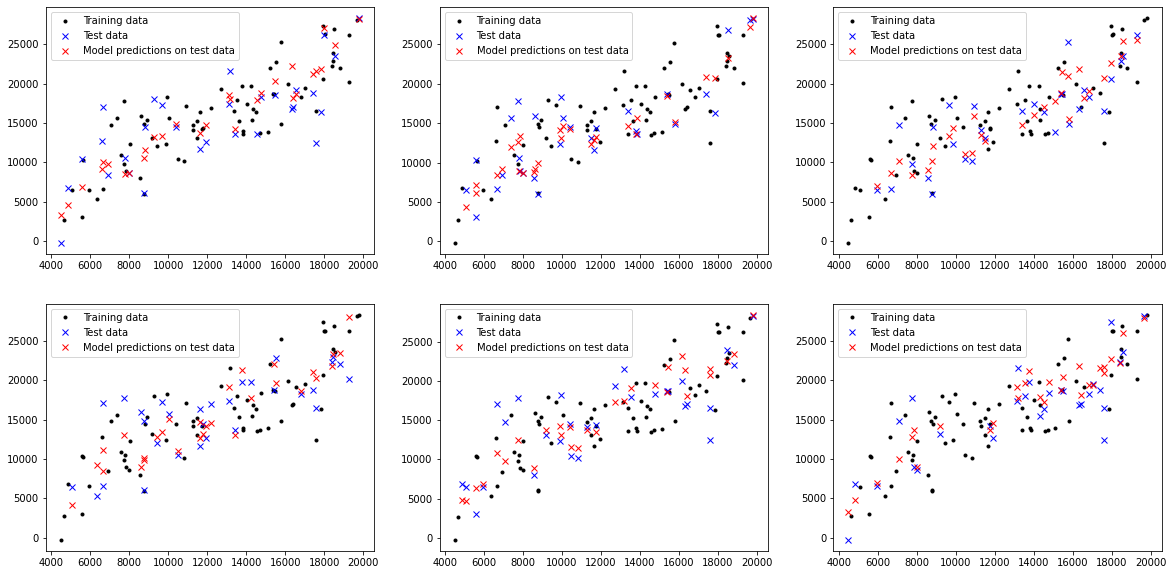

In [125]:
area_mu_0 = range(3,6)
volume_mu_0 = range(15,23)
storeys_mu_0 = range(3,6)
alphas = np.linspace(0.000001, 0.00001, 10)
betas = np.linspace(0.00001, 0.001, 10)
best_log_lik = -np.inf
best_tst_error = np.inf
logliks = []

# X_tr = X
# X_tst = generated_data[["Area", "Volume", "Storeys"]].values
# y_tr = concrete
# y_tst = generated_data[["Concrete"]].values

for area_mu in area_mu_0:
  for volume_mu in volume_mu_0:
    for storeys_mu in storeys_mu_0:
      for alpha in alphas:
        for beta in betas:
          res = np.zeros(10)
          mu_0 = np.array([area_mu, volume_mu, storeys_mu])
          for i in range(10):

            X_tr, X_tst, y_tr, y_tst = train_test_split(
                X, concrete, test_size=0.3)

            # centers = np.array([np.linspace(0, 2, 20), np.linspace(0, 7, 20)]).T
            # lambdaval = -1
            # X_input = radial_bf(X_tr, centers, lambdaval)[:, 0, :]
            # X_test = radial_bf(X_tst, centers, lambdaval)[:, 0, :]

            X_input = identity_bf(X_tr)
            X_test = identity_bf(X_tst)
            post_mu, post_S, log_lik_candidate = BLR(
                X_input, y_tr, alpha, beta, mu_0)

            # weights = np.random.multivariate_normal(post_mu, post_S)
            # y_pred = X_test @ weights
            # err = mean_squared_error(y_tst, y_pred)
            res[i] = log_lik_candidate

          mean_loglik = np.mean(res)
          logliks.append(mean_loglik)

          if mean_loglik > best_log_lik:
            # best_tst_error = mean_err
            best_log_lik = mean_loglik
            best_alpha = alpha
            best_beta = beta
            best_mu_0 = mu_0

params = pd.DataFrame({
    'Parameter': ['alpha', 'beta', 'mu0'],
    'Value': [best_alpha, best_beta, best_mu_0]
})

plt.plot(logliks[::100].copy())
display(params)
fig = plt.figure(figsize=[20.0, 10.0])
errs = np.zeros(6)

for i in range(6):
  X_tr, X_tst, y_tr, y_tst = train_test_split(
      X, concrete, test_size=0.3)

  # centers = np.array([np.linspace(0, 2, 20), np.linspace(0, 7, 20)]).T
  # lambdaval = -1
  # X_input = radial_bf(X_tr, centers, lambdaval)[:, 0, :]
  # X_test = radial_bf(X_tst, centers, lambdaval)[:, 0, :]

  X_input = identity_bf(X_tr)
  X_test = identity_bf(X_tst)
  best_mu, best_S, loglik = BLR(X_input, y_tr, best_alpha, best_beta, best_mu_0)

  sampled_weights = np.random.multivariate_normal(best_mu, best_S)
  y_pred = X_test @ sampled_weights
  errs[i] = np.sqrt(mean_squared_error(y_tst, y_pred))

  plt.subplot(230 + i + 1)
  plt.plot(X_tr[:, 0], y_tr, '.k', label='Training data')
  plt.plot(X_tst[:, 0], y_tst, 'bx', label='Test data')
  plt.plot(X_tst[:, 0], y_pred, 'rx',
          label='Model predictions on test data')
  plt.legend()

print(errs)
plt.show()


# Predictive distribution using simple posterior sampling

In [126]:
def predict(x, sample_size=1000, confidence=0.95):

  weight_samples = np.random.multivariate_normal(best_mu, best_S, size=sample_size)
  preds = weight_samples @ x
  pred_mean = np.mean(preds)
  q_1 = np.quantile(preds, 1-confidence)
  q_2 = np.quantile(preds, confidence)

  prediction = {
    "Prediction mean": pred_mean,
    "Confidence": confidence,
    "Interval": (q_1, q_2)
  }
  
  return prediction

print(best_S)

test_input = X_tst[0, :]
test_real_out = y_tst[0].item()
pred = predict(test_input)
print("Input:")
print(test_input)
print("Actual value:")
print(test_real_out)
print("Prediction:")
print(pred)

[[ 1.46300869e-03 -2.33043021e-05 -4.13151621e+00]
 [-2.33043021e-05  1.04198273e-03 -1.08494273e+01]
 [-4.13151621e+00 -1.08494273e+01  1.26130574e+05]]
Input:
[1.37732854e+04 4.08810476e+04 4.00000000e+00]
Actual value:
19718.86477754012
Prediction:
{'Prediction mean': 21087.918660847157, 'Confidence': 0.95, 'Interval': (20949.047580270202, 21226.149325181494)}
